#### **Práctica 2: Señales discretas**

**Integrantes**

Luisa María Martínez Muelas

Carolina Taborda Vargas

#### **Resumen**

Esta práctica presenta la implementación y análisis de las señales discretas elementales mediante Python, con el fin de afianzar los conceptos fundamentales del procesamiento digital de señales. Se programaron funciones para generar el impulso unitario, el escalón unitario, la rampa, exponenciales complejas y señales sinusoidales discretas, y se construyeron secuencias más complejas a partir de combinaciones lineales de estas funciones. Adicionalmente, se exploró el cálculo de la derivada discreta mediante diferencias finitas y se aplicaron operaciones de desplazamiento, escalado y modulación sobre secuencias. Los resultados obtenidos permiten comprender las diferencias esenciales entre el procesamiento en tiempo continuo y en tiempo discreto, así como las implicaciones prácticas de trabajar con un número finito de muestras.

In [ ]:
#Importación de librerías
import numpy as np
import matplotlib.pyplot as plt

#### **Función discreta**

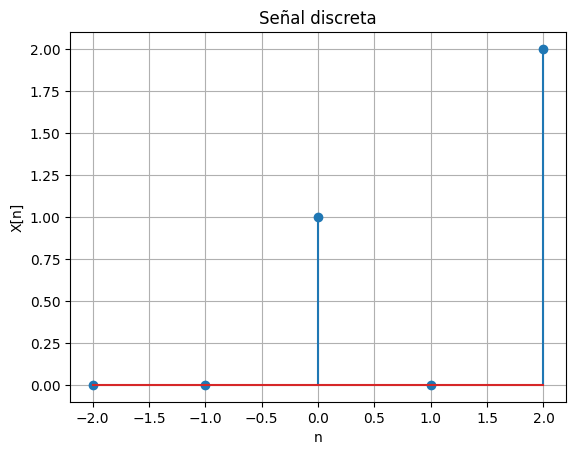

In [ ]:

n=np.array([-2,-1,0,1,2]) 
x=np.array([0,0,1,0,2]) 

plt.stem(n,x)
plt.xlabel('n')
plt.ylabel('X[n]')
plt.title('Señal discreta')
plt.grid()


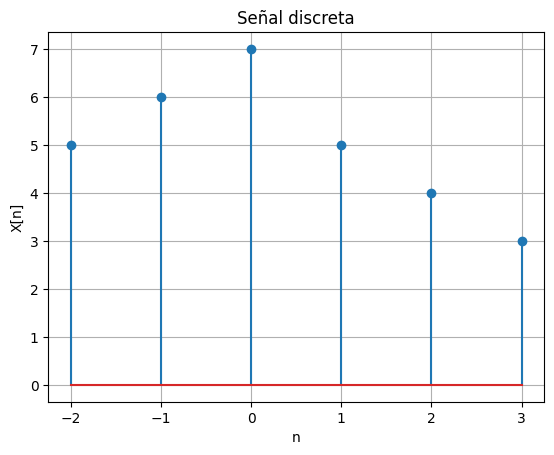

In [ ]:

n=np.array([-2,-1,0,1,2,3]) 
x=np.array([5,6,7,5,4,3])

plt.stem(n,x)
plt.xlabel('n')
plt.ylabel('X[n]')
plt.title('Señal discreta')
plt.grid()

#### **Función impulso unitario**

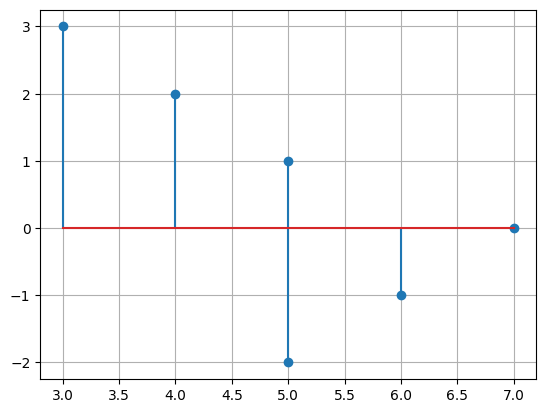

In [23]:
def impulso_unitario(n0,n1,n2):
    n=np.arange(n1,n2+1)
    x=(n==n0).astype(int)
    return x,n

impulso_unitario(1,1,2)
plt.stem(x,n)
plt.grid()
plt.show()

#### **1. Función escalón unitario**

n = [-3 -2 -1  0  1  2  3]
u(n) = [0 0 0 1 1 1 1]


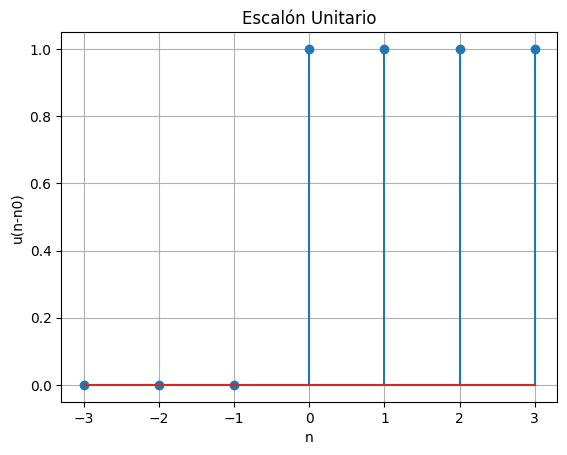

In [24]:
def escalon_unitario(n0,n1,n2):
    
    if n1 > n2:
        raise ValueError("n1 debe ser menor o igual que n2")
    
    #Vector de muestras
    n=np.arange(n1,n2+1)

    #Condición escalón
    u=np.where(n>=n0, 1,0)
    return n,u

n,u= escalon_unitario(0,-3,3)

print("n =", n)
print("u(n) =", u)

# Gráfica
plt.stem(n, u)
plt.title("Escalón Unitario")
plt.xlabel("n")
plt.ylabel("u(n-n0)")
plt.grid(True)
plt.show()


#### **2. Función rampa**

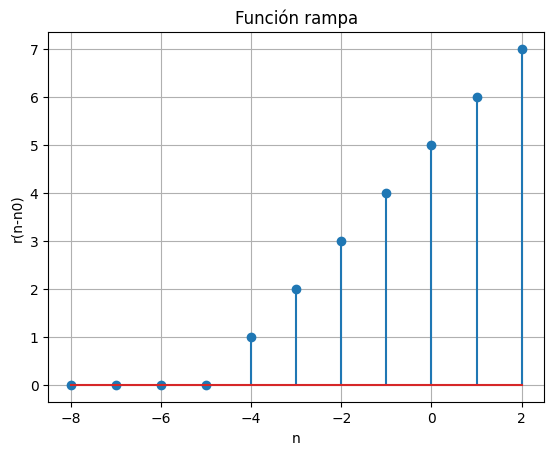

In [25]:
def rampa(n0,n1,n2,m):

    n=np.arange(n1,n2+1)

    #Rampa
    r=np.where(n>=n0, m*(n-n0),0)
    return n,r
n,r=rampa(-5,-8,2,1)
plt.stem(n,r)
plt.title('Función rampa')
plt.xlabel('n')
plt.ylabel('r(n-n0)')
plt.grid()


#### **3. Exponenciales complejas**

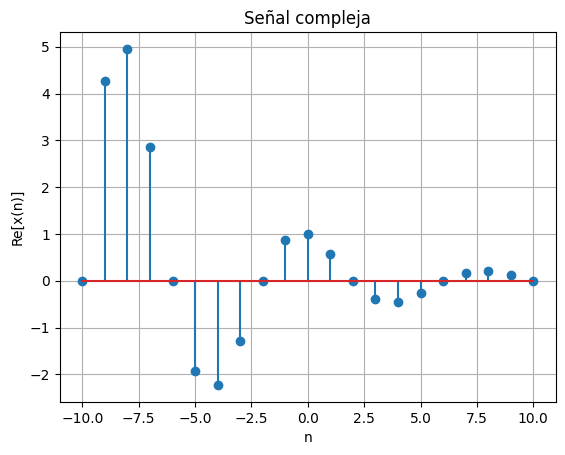

In [ ]:

def func_comp(sigma, w0, n1, n2):

    n = np.arange(n1, n2+1)

    x = np.exp((sigma + 1j*w0) * n)

    return n, x

n, x = func_comp(-0.2, np.pi/4, -10, 10)

plt.stem(n, np.real(x))
plt.xlabel('n')
plt.ylabel('Re[x(n)]')
plt.title('Señal compleja')
plt.grid()
plt.show()

#### **4. Función senosoidal discreta**

y(n)=Asin(ω0​n+ϕ)

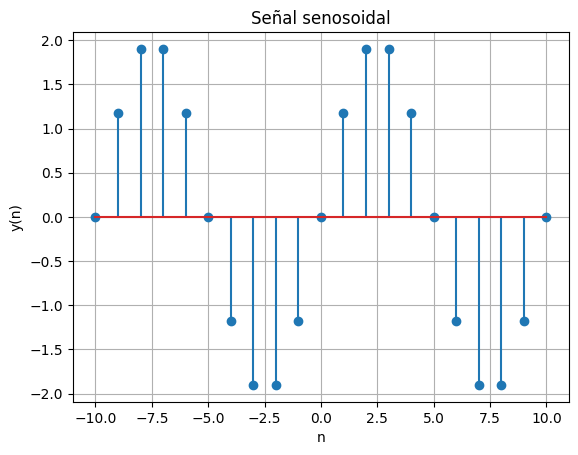

In [ ]:
def sin_signal(n1, n2, A, f, phi=0):

    n = np.arange(n1, n2+1)

    w0 = 2*np.pi*f

    y = A * np.sin(w0*n + phi)

    return n, y

n, y = sin_signal(-10, 10, 2, 0.1)

plt.stem(n, y)
plt.xlabel('n')
plt.ylabel('y(n)')
plt.title('Señal senosoidal')
plt.grid()
plt.show()

#### **5. Sinusoides**

$x(n)=\sin(\omega_0 n + \theta_0)$

**1. Secuencia 𝑥1(𝑛)= 3𝛿(𝑛+1)+5𝛿(𝑛+3)+3𝛿(𝑛+2)+3𝛿(𝑛)+ 𝛿(𝑛):**

El vector de muestras debe cubrir desde el menor índice hasta el mayor índice: n=−3,−2,−1,0. Esto nos permite generar un total de 4 muestras, en el cual se construye una señal discreta a partir de pulsos desplazados. 

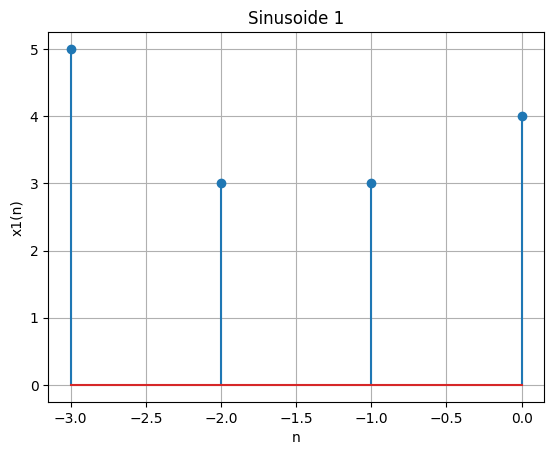

In [ ]:

n = np.arange(-3,1)

x = np.zeros(len(n))

x[n == -3] = 5
x[n == -2] = 3
x[n == -1] = 3
x[n == 0]  = 4

plt.stem(n,x)
plt.xlabel('n')
plt.ylabel('x1(n)')
plt.title('Sinusoide 1')
plt.grid()
plt.show()

 **2. Secuencia:  𝑥4(𝑛)= 2𝑟(𝑛+3)−𝑟(𝑛−2)−5𝑢(𝑛−3),−10≤𝑛≤10**

 Para realizar la secuencia, se tiene en cuenta que está conformada por las funciones escalón unitario y rampa. Para ello, llamamos las funciones realizadas anteriormente para conformar esta secuencia con los desplazamientos indicados

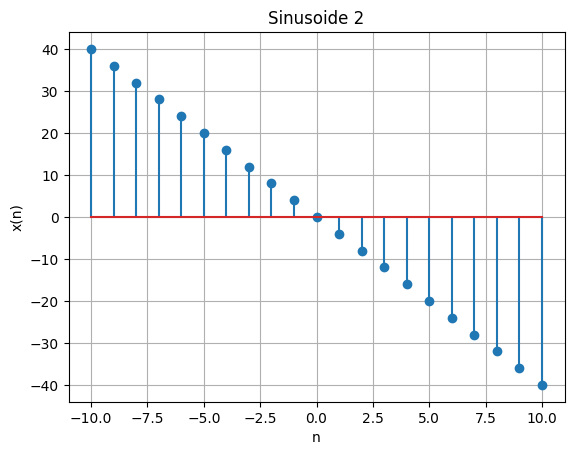

In [ ]:
n1 = -10
n2 = 10


r1,_ = rampa(-3,n1,n2,1)
r2,_ = rampa(2,n1,n2,1)
u1,_ = escalon_unitario(3,n1,n2)

x4 = 2*r1 - r2 - 5*u1
n = np.arange(n1,n2+1)

#Gráfica
plt.stem(n,x4)
plt.title("Sinusoide 2")
plt.xlabel('n')
plt.ylabel('x(n)')
plt.grid()
plt.show()

#### **6. Secuencia**

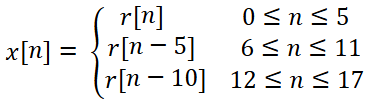

**Derivada de la secuencia**

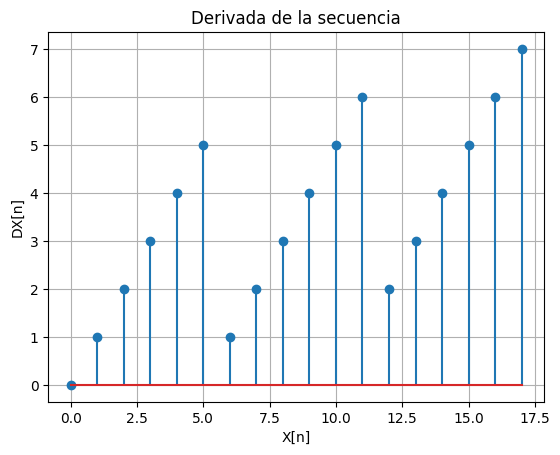

In [ ]:

#Creamos la derivada de la secuencia

n = np.arange(0,18)

x = np.zeros(len(n))

for i in range(len(n)):
    if 0 <= n[i] <= 5:
        x[i] = n[i]
    elif 6 <= n[i] <= 11:
        x[i] = n[i]-5
    elif 12 <= n[i] <= 17:
        x[i] = n[i]-10

#Gráfica
plt.stem(n,x)
plt.title('Derivada de la secuencia')
plt.xlabel('X[n]')
plt.ylabel('DX[n]')
plt.grid()
plt.show()

**Secuencia original y derivada**

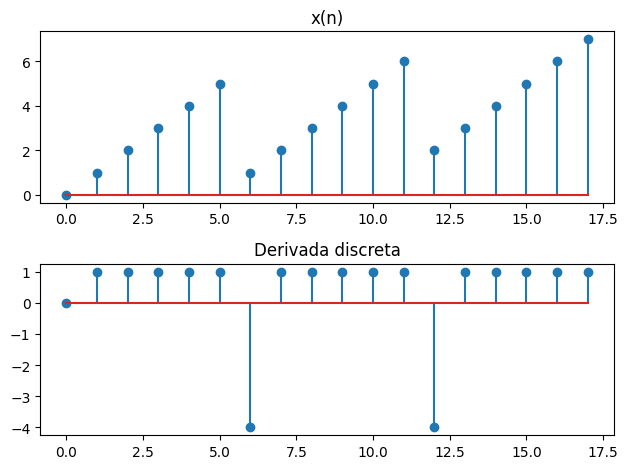

In [ ]:
#Creación de las variables de secuencia original y derivada 

dx = np.diff(x)
dx = np.insert(dx,0,0)

#Gráfica
plt.subplot(2,1,1)
plt.stem(n,x)
plt.title("x(n)")

plt.subplot(2,1,2)
plt.stem(n,dx)
plt.title("Derivada discreta")

plt.tight_layout()
plt.show()

La derivada no es igual a la derivada del caso continuo porque en tiempo discreto usamos diferencias finitas, es decir, no hay infinitos puntos; solo existen cambios entre muestras 

#### **7. Secuencia 𝑥(𝑛)={0,1,2,3,4,5̂,4,3,2,1,0,1,2,3,4,5,5,5,5,10,10,10,10}**

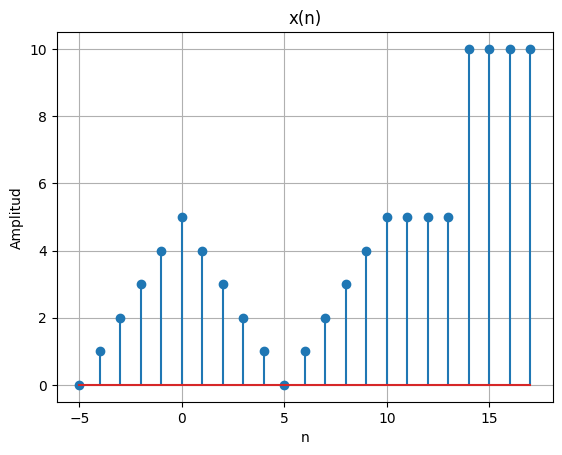

In [ ]:
#Arreglo de la secuencia 
x = np.array([0,1,2,3,4,5,4,3,2,1,0,1,2,3,4,5,5,5,5,10,10,10,10])
n = np.arange(-5,18)

#Gráfica
plt.stem(n,x)
plt.title("x(n)")
plt.xlabel('n')
plt.ylabel('Amplitud')
plt.grid()
plt.show()

**a. 𝑥5(𝑛)=2𝑥(𝑛−4)+𝑥(𝑛)**

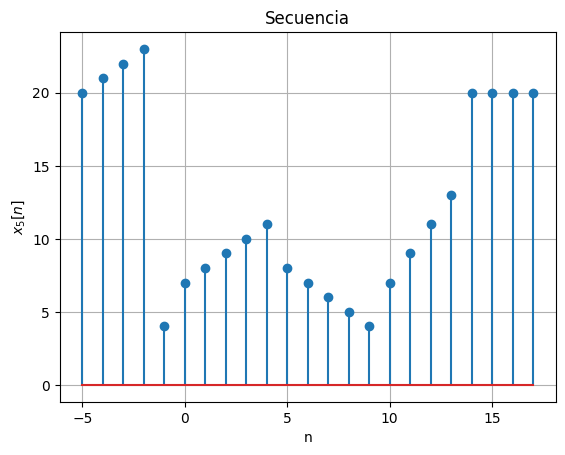

In [ ]:

n = np.arange(-5, -5 + len(x)) 

# Cálculo de x5
x5 = 2 * np.roll(x, 4) + x

# Gráfica
plt.stem(n, x5)
plt.title('Secuencia')
plt.xlabel('n')
plt.ylabel('$x_5[n]$')
plt.grid()
plt.show()

**b. 𝑥6(𝑛)=0.001𝑒0.5𝑛𝑥(𝑛)+10𝑠𝑖𝑛(0.05𝜋𝑛)𝑥(𝑛+2),−20≤𝑛≤20**

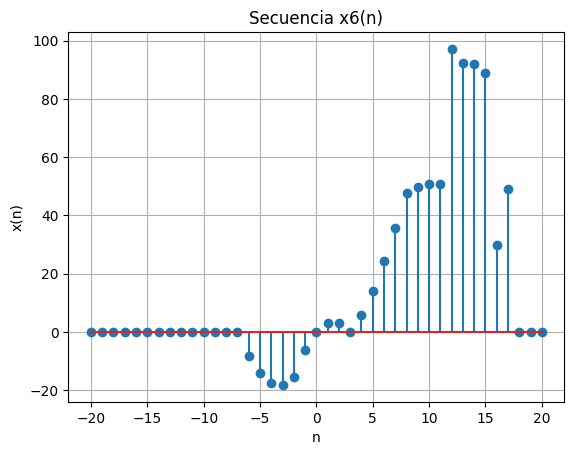

In [34]:
n = np.arange(-20,21)

x_interp = np.interp(n, np.arange(-5,18), x, left=0, right=0)

x_shift2 = np.roll(x_interp,-2)

x6 = 0.001*np.exp(0.5*n)*x_interp + 10*np.sin(0.05*np.pi*n)*x_shift2

plt.stem(n,x6)
plt.title("Secuencia x6(n)")
plt.xlabel('n')
plt.ylabel('x(n)')
plt.grid()
plt.show()

La práctica permitió comprobar que las señales discretas elementales, como el impulso, el escalón y la rampa, son la base para construir secuencias más complejas mediante combinaciones lineales. Además, se evidenció que su implementación en Python utilizando NumPy es directa y eficiente.

También se observó que la derivada discreta, al calcularse mediante diferencias finitas, no es equivalente a la derivada continua, ya que únicamente representa los cambios entre muestras consecutivas y no considera valores intermedios. Por último, se identificó que, para operar correctamente con señales definidas en distintos dominios, es necesario alinearlas sobre un mismo vector de muestras, empleando procesos de interpolación cuando se requiere.